# Robustness of Accessibility
## Notebook 3/4 - Draw samples, calculate distances and scores

In [1]:
from __future__ import annotations 
 
import datetime 
import time 
import json 
from shapely.geometry import shape 
import osmnx as ox 
import geopandas as gpd 
from shapely.ops import unary_union 
from shapely.geometry import Point 
import folium 
 
import os 
from pathlib import Path 
 
p = Path.cwd().resolve() 
while not (p / 'css_geodata_service').exists() and p.parent != p: 
    p = p.parent 
os.chdir(p) 
print('CWD reset to repo root:', Path.cwd()) 
 
from css_geodata_service.robustness_of_accessibility.examples.notebooks.notebook_utils import ( 
    RoaNotebookConfig, 
    get_roa_cache_path, 
    get_roa_inputs_path, 
    get_roa_outputs_path, 
) 
 
# ox.config(use_cache=True, log_console=True) 
ox.settings.log_console = False 
ox.settings.use_cache = True 
 
ox.__version__ 


CWD reset to repo root: C:\Users\baiis\Desktop\roa_fopra


'1.9.3'

In [2]:
event = RoaNotebookConfig.event 
 
inputs_dir: Path = get_roa_inputs_path() 
cache_dir: Path = get_roa_cache_path() 
output_dir: Path = get_roa_outputs_path() 


Working dir set to: C:\Users\baiis\Desktop\roa_fopra
Working dir set to: C:\Users\baiis\Desktop\roa_fopra
Working dir set to: C:\Users\baiis\Desktop\roa_fopra


In [3]:
# set globals:
start_time_global = time.time()
place_name: str = RoaNotebookConfig.place_name
undirected_graph: bool = RoaNotebookConfig.undirected_graph

show_all_graph = False

### Create  basic graph of Trier

In [4]:
# load networks for calculation
road_network = ox.load_graphml(cache_dir / f"network/drive_graph_{place_name}.graphml")
road_network_remaining = ox.load_graphml(cache_dir / f"network/drive_graph_remaining_{place_name}.graphml")

#### Make graph undirected since services might ignore one way roads

In [5]:
# make graph undirected to allow services to move in both directions
if undirected_graph:
    road_network = road_network.to_undirected()
    road_network_remaining = road_network_remaining.to_undirected()

#### Optionally add speed information to calculate travel time of edges

In [6]:
# impute speed on all edges missing data
road_network_remaining = ox.add_edge_speeds(road_network_remaining)
road_network = ox.add_edge_speeds(road_network)

# calculate travel time (seconds) for all edges
road_network_remaining = ox.add_edge_travel_times(road_network_remaining)
road_network = ox.add_edge_travel_times(road_network)

In [7]:
## 1. convert the graph to GeoDataFrame
road_network_remaining_nodes, road_network_remaining_edges = ox.graph_to_gdfs(road_network_remaining)
road_network_nodes, road_network_edges = ox.graph_to_gdfs(road_network)

### Define evacuation area

In [8]:
# Evacuation circle around bomb discovery point 
bomb_scenarios_path = output_dir / f"bomb_scenarios_{place_name}.geojson"
bomb_scenarios = gpd.read_file(bomb_scenarios_path)

scenario_id = 21
row = bomb_scenarios[bomb_scenarios["scenario_id"] == scenario_id].iloc[0]
bomb_lon = row.geometry.x
bomb_lat = row.geometry.y
radius_m = 1000 
 
# Buffer in projected CRS for a true circle in meters, then reproject to WGS84 
pt = gpd.GeoSeries([Point(bomb_lon, bomb_lat)], crs='EPSG:4326') 
pt_utm = pt.to_crs('EPSG:32632') 
evacuation_area_utm = pt_utm.buffer(radius_m) 
evacuation_area_gdf = evacuation_area_utm.to_crs('EPSG:4326') 
evacuation_area = evacuation_area_gdf.iloc[0] 


In [9]:
hospitals = gpd.read_file(cache_dir / f"services/hospitals_{place_name}.geojson")
fire_stations = gpd.read_file(cache_dir / f"services/fire_stations_{place_name}.geojson")
administrative_districts = gpd.read_file(cache_dir / f"services/administrative_districts_{place_name}.geojson")

Skipping field ways: unsupported OGR type: 1
Skipping field ways: unsupported OGR type: 1
Skipping field ways: unsupported OGR type: 1


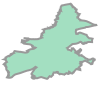

In [10]:
with open(cache_dir / f"services/boundary_geom_{place_name}.geojson", "r") as f:
    # as_string = f.read()
    geom_dict = json.load(f)  # → a plain GeoJSON *geometry* dict
boundary_geom = shape(geom_dict)  # → Shapely Polygon or MultiPolygon
boundary_geom

In [11]:
# refactor using default functon 
from css_geodata_service.robustness_of_accessibility.robustness_of_accessibility import (
    get_nearest_node_id,
    get_node_point_from_node_id,
)


def prepare_services(services: gpd.GeoDataFrame, drive_service_graph) -> gpd.GeoDataFrame:
    print("Prepare services")
    services = services.copy(deep=True)
    services["nearest_node_id"] = services["position"].apply(
        lambda point: get_nearest_node_id(point=point, graph=drive_service_graph)
    )

    street_network_nodes, _ = ox.graph_to_gdfs(drive_service_graph)
    services["nearest_node_point"] = services["nearest_node_id"].apply(
        lambda node_id: get_node_point_from_node_id(nodes=street_network_nodes, node_id=node_id)
    )
    return services

In [12]:
fire_stations["position"] = fire_stations["geometry"].centroid
new_fire_stations = prepare_services(fire_stations, road_network)

C:\Users\baiis\AppData\Local\Temp\ipykernel_9668\4087542079.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fire_stations["position"] = fire_stations["geometry"].centroid


Prepare services


In [13]:
# filter hospitals that are relevant i.e. have a emergency reception
hospitals = hospitals.loc[hospitals["emergency"] == "yes"]
hospitals

,element_type,osmid,emergency,wheelchair,opening_hours,operator,name,website,nodes,amenity,...,phone,source,contact:phone,healthcare:speciality,old_name,toilets:wheelchair,alt_name,short_name,type,geometry
0,way,29977497,yes,yes,24/7,None,Klinikum Mutterhaus der Borromäerinnen Trier,https://www.mutterhaus.de/,"[ 5246812910, 7889582620, 7889582621, 52468129...",hospital,...,None,None,None,None,None,None,None,None,None,"POLYGON ((6.63277 49.75348, 6.6327 49.75332, 6..."
1,way,1323681259,yes,yes,24/7,Klinikum Mutterhaus der Borromäerinnen gGmbH,Klinikum Mutterhaus der Borromäerinnen Nord,None,"[ 4506594637, 4506594635, 2628661352, 26286613...",hospital,...,None,http://www.mutterhaus.de/klinikum-mutterhaus-n...,+49 651 683 0,internal;plastic_surgery,Evangelisches Elisabeth-Krankenhaus,yes,None,None,None,"POLYGON ((6.6427 49.76217, 6.64269 49.76208, 6..."
2,relation,6786740,yes,None,24/7,None,Krankenhaus der Barmherzigen Brüder Trier,http://www.bk-trier.de,"[ [ [ 4550461569, 4550461571, 4550461572, 3307...",hospital,...,+49 651 208-0,None,None,None,None,None,Brüderkrankenhaus Trier,BKT,multipolygon,"POLYGON ((6.63729 49.76287, 6.63747 49.763, 6...."


In [14]:
# since osm data is often not perfect and we might have special knowledge we can manually adapt the data to make it more realistic
# we exclude Klinikum Mutterhaus der Borromäerinnen Nord since it actually has no emergency reception
hospitals = hospitals[hospitals["name"] != "Klinikum Mutterhaus der Borromäerinnen Nord"]

In [15]:
hospitals.reset_index(inplace=True, drop=True)
hospitals

,element_type,osmid,emergency,wheelchair,opening_hours,operator,name,website,nodes,amenity,...,phone,source,contact:phone,healthcare:speciality,old_name,toilets:wheelchair,alt_name,short_name,type,geometry
0,way,29977497,yes,yes,24/7,None,Klinikum Mutterhaus der Borromäerinnen Trier,https://www.mutterhaus.de/,"[ 5246812910, 7889582620, 7889582621, 52468129...",hospital,...,None,None,None,None,None,None,None,None,None,"POLYGON ((6.63277 49.75348, 6.6327 49.75332, 6..."
1,relation,6786740,yes,None,24/7,None,Krankenhaus der Barmherzigen Brüder Trier,http://www.bk-trier.de,"[ [ [ 4550461569, 4550461571, 4550461572, 3307...",hospital,...,+49 651 208-0,None,None,None,None,None,Brüderkrankenhaus Trier,BKT,multipolygon,"POLYGON ((6.63729 49.76287, 6.63747 49.763, 6...."


### Disclaimer about coordinates:
- Shapely uses: (lon, lat)
- Folium / leaflet uses (lat, lon)

### Fix hospital emergency access location 
- Hospitals are big buildings with a sometimes lot of adjecent roads
- Hospitals are big buildings and usually not part of the road network itself
- Calculating a route to a hospital via the nearest node to the centroid of the geometry may be unrealsitic 
- The following section is used to manually select / define the nearst access / node for every hospital in order to ensure that routes are realistic.
- identified node ids are used later for routing

In [16]:
hospitals.loc[:, "position"] = None
hospitals

c:\Users\baiis\Desktop\roa_fopra\.venv\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,element_type,osmid,emergency,wheelchair,opening_hours,operator,name,website,nodes,amenity,...,source,contact:phone,healthcare:speciality,old_name,toilets:wheelchair,alt_name,short_name,type,geometry,position
0,way,29977497,yes,yes,24/7,None,Klinikum Mutterhaus der Borromäerinnen Trier,https://www.mutterhaus.de/,"[ 5246812910, 7889582620, 7889582621, 52468129...",hospital,...,None,None,None,None,None,None,None,None,"POLYGON ((6.63277 49.75348, 6.6327 49.75332, 6...",None
1,relation,6786740,yes,None,24/7,None,Krankenhaus der Barmherzigen Brüder Trier,http://www.bk-trier.de,"[ [ [ 4550461569, 4550461571, 4550461572, 3307...",hospital,...,None,None,None,None,None,Brüderkrankenhaus Trier,BKT,multipolygon,"POLYGON ((6.63729 49.76287, 6.63747 49.763, 6....",None


In [17]:
hospitals.loc[hospitals["name"] == "Klinikum Mutterhaus der Borromäerinnen Trier", "position"] = Point(
    6.632108, 49.754674
)
hospitals.loc[(hospitals["name"] == "Krankenhaus der Barmherzigen Brüder Trier"), "position"] = Point(
    6.640020, 49.761562
)

In [18]:
hospitals["nearest_node_id"] = hospitals["position"].apply(
    lambda point: get_nearest_node_id(point=point, graph=road_network)
)

c:\Users\baiis\Desktop\roa_fopra\.venv\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [19]:
hospitals["nearest_node_id"] = hospitals["position"].apply(
    lambda point: get_nearest_node_id(point=point, graph=road_network)
)
hospital_nodes_df = road_network_remaining_nodes.loc[hospitals["nearest_node_id"]].reset_index()
# nodes_df.reset_index(inplace=True)
hospitals["nearest_node_point"] = hospital_nodes_df["geometry"]
hospitals.head()

c:\Users\baiis\Desktop\roa_fopra\.venv\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\baiis\Desktop\roa_fopra\.venv\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,element_type,osmid,emergency,wheelchair,opening_hours,operator,name,website,nodes,amenity,...,healthcare:speciality,old_name,toilets:wheelchair,alt_name,short_name,type,geometry,position,nearest_node_id,nearest_node_point
0,way,29977497,yes,yes,24/7,None,Klinikum Mutterhaus der Borromäerinnen Trier,https://www.mutterhaus.de/,"[ 5246812910, 7889582620, 7889582621, 52468129...",hospital,...,None,None,None,None,None,None,"POLYGON ((6.63277 49.75348, 6.6327 49.75332, 6...",POINT (6.632108 49.754674),1411540125,POINT (6.63222 49.75459)
1,relation,6786740,yes,None,24/7,None,Krankenhaus der Barmherzigen Brüder Trier,http://www.bk-trier.de,"[ [ [ 4550461569, 4550461571, 4550461572, 3307...",hospital,...,None,None,None,Brüderkrankenhaus Trier,BKT,multipolygon,"POLYGON ((6.63729 49.76287, 6.63747 49.763, 6....",POINT (6.64002 49.761562),1624129404,POINT (6.63916 49.76191)


In [20]:
region_center = boundary_geom.centroid
print(f"x={region_center.x} y={region_center.y}")

x=6.655662648430245 y=49.76274829954864


### Visualization only (hospitals)

In [21]:
from css_geodata_service.robustness_of_accessibility.utils.utils import (
    add_points_from_df_to_folium_map,
)


hospital_map = folium.Map(location=[region_center.y, region_center.x], zoom_start=13)

hospital_map = add_points_from_df_to_folium_map(df=hospitals, folium_map=hospital_map, column="position", text="Access")
hospital_map = add_points_from_df_to_folium_map(
    df=hospitals,
    folium_map=hospital_map,
    column="nearest_node_point",
    text="Nearest Node",
)
# hospital_map

### Fires Stations
- Fire Stations are much smaller compared to hospitals so we just use the centroid

In [22]:
# set position for each fire station
fire_stations["position"] = fire_stations["geometry"].centroid

C:\Users\baiis\AppData\Local\Temp\ipykernel_9668\298202662.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fire_stations["position"] = fire_stations["geometry"].centroid


In [23]:
fire_stations["nearest_node_id"] = fire_stations["position"].apply(
    lambda point: get_nearest_node_id(point=point, graph=road_network)
)
fire_station_nodes_df = road_network_nodes.loc[fire_stations["nearest_node_id"]].reset_index()
# nodes_df.reset_index(inplace=True)
fire_stations["nearest_node_point"] = fire_station_nodes_df["geometry"]

### Visualization only (fire stations)

In [24]:
fire_station_map = folium.Map(location=[region_center.y, region_center.x], zoom_start=13, tiles="CartoDB positron")

fire_station_map = add_points_from_df_to_folium_map(
    df=fire_stations, folium_map=fire_station_map, column="position", text="Centroid"
)
fire_station_map = add_points_from_df_to_folium_map(
    df=fire_stations,
    folium_map=fire_station_map,
    column="nearest_node_point",
    text="Nearest Node",
)
# fire_station_map

### Exclude the boundaries that do not have a name or those that have more than one district (hierarchy)

In [25]:
districts_filtered = administrative_districts.loc[administrative_districts["name"].notnull()]
print(f"districts_filtered with name = {len(districts_filtered)} all boundaries = {len(administrative_districts)}")

districts_filtered with name = 78 all boundaries = 248


### Visualize the district boundaries in the area with their names

In [26]:
combined_district_polygon = unary_union(districts_filtered.geometry)
gdf_combined_district_polygons = gpd.GeoDataFrame(geometry=[combined_district_polygon])

In [27]:
from css_geodata_service.robustness_of_accessibility.robustness_of_accessibility import draw_sample

# TODO before drawing a sample we must ensure the buffer
samples = draw_sample(boundary_geom, road_network_nodes, sample_distance_in_meters=50)

c:\Users\baiis\Desktop\roa_fopra\.venv\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [28]:
# filter samples to only those that are within a considered administrative adrea
print(f"number of (pre-filtered) samples = {len(samples)}")
samples["within_polygon"] = samples["geometry"].apply(lambda point: combined_district_polygon.contains(point))
df_node_samples_within_polygon = samples[samples["within_polygon"]].drop(labels="within_polygon", axis=1)
print(f"number of (filtered) samples = {len(df_node_samples_within_polygon)}")

number of (pre-filtered) samples = 3913
number of (filtered) samples = 3913


<Axes: >

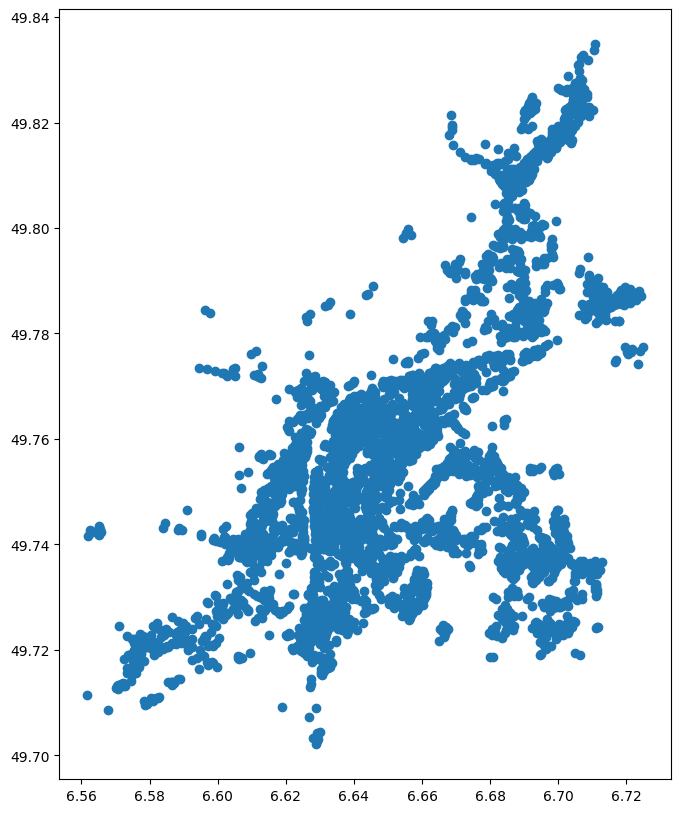

In [29]:
df_node_samples_within_polygon.plot(figsize=(10, 10))

In [30]:
# filter samples for testing
sub_sample = False
if sub_sample:
    df_node_samples_within_polygon_sample = df_node_samples_within_polygon.sample(frac=0.01, random_state=42)
    print(
        f" original number of samples = {len(df_node_samples_within_polygon)}, sampled number = {len(df_node_samples_within_polygon_sample)}"
    )
    df_node_samples_within_polygon = df_node_samples_within_polygon_sample

In [31]:
from css_geodata_service.robustness_of_accessibility.utils.models import NodeDetails
from css_geodata_service.robustness_of_accessibility.utils.utils import (
    calculate_routes,
    create_distance_df,
)

start = time.time()
print("Calculate RoA distances and scores")

poi = {"fire_stations": fire_stations, "hospitals": hospitals}
results: dict[str, dict] = {"normal": {}, "disrupted": {}}
for state in results.keys():
    s = time.time()
    network = None
    if state == "normal":
        network = road_network
    if state == "disrupted":
        network = road_network_remaining
    # calculate routes to services in both states
    node_details: list[NodeDetails] = calculate_routes(
        samples=samples, services=poi, street_network=network, state=state
    )
    print(f"{round((time.time() - s) / 60, 2)} minutes elapsed for {state} street network")
    distances = create_distance_df(node_details)
    # split up service types
    for service_type in distances["service_type"].unique():
        results[state][service_type] = distances[distances["service_type"] == service_type]
end = time.time()
print(f"Calculate RoA elapsed time: {end - start}")

Calculate RoA distances and scores
0.22 minutes elapsed for normal street network
0.2 minutes elapsed for disrupted street network
Calculate RoA elapsed time: 25.41472887992859


In [32]:
from css_geodata_service.robustness_of_accessibility.robustness_of_accessibility import calculate_roa_scores

scores = calculate_roa_scores(results)

# Wenn Service-Nodes im Evakuationskreis, score = 0
service_nodes = set()
for gdf in [fire_stations, hospitals]:
    if "nearest_node_id" in gdf.columns:
        service_nodes |= set(gdf["nearest_node_id"])

for service_type, df in scores.items():
    df = df.copy()
    df["geometry"] = df["to_centroid"]
    df = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")

    mask = df.within(evacuation_area) & df["to_node_id"].isin(service_nodes)
    df.loc[mask, "score"] = 0

    # zurück in scores-Dict
    scores[service_type] = df.drop(columns=["geometry"])

### Write results to file

In [33]:
now: datetime.datetime = datetime.datetime.now()
now_str = now.strftime("%Y-%m-%d_%H-%M-%S")

In [34]:
for service_type in scores.keys():
    scores_for_service = scores[service_type]
    scores_for_service.to_csv(output_dir / f"scores_21{service_type}_{now_str}.csv")
now_str

'2026-03-19_15-05-01'

In [35]:
# Record the end time
end_time_global = time.time()

# Calculate the time elapsed between the two commands
elapsed_time_global = end_time_global - start_time_global

In [36]:
print(f"{round(elapsed_time_global / 60, 2)} minutes elapsed for total process")

0.55 minutes elapsed for total process
